In [1]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    # Monta il drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Inserisci qui il percorso esatto della cartella su Drive.
    # Se è una cartella condivisa standard di cui avete creato una scorciatoia 
    # nel vostro Drive personale, il percorso sarà simile a questo:
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
    
    # Se invece è un "Drive Condiviso" aziendale/universitario:
    # BASE_PATH = '/content/drive/Shareddrives/Nome_Drive/Nome_Progetto/'

else:
    print("Ambiente locale rilevato.")
    # Imposta la directory base in locale. 
    # './' significa la cartella in cui si trova attualmente il notebook.
    # Oppure usa '../' se i notebook sono in una sottocartella e i dati fuori.
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import

In [2]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight

I0000 00:00:1781209690.341981    4146 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781209691.392694    4146 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781209695.213884    4146 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Download dei dati generati

In [3]:
DEST_DIR = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned')
ZIP_PATH = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned', 'generated_sd.zip')
SYNTHETIC_DRIVE_ID = '1We35Eg-pH1fBPhM4zZLQDtOIhECo6ZUR'

def synthetic_data_ready():
    if not os.path.isdir(DEST_DIR):
        return False
    return any(f.endswith('.png') for f in os.listdir(DEST_DIR))

os.makedirs(DEST_DIR, exist_ok=True)

if not synthetic_data_ready():
    print("Immagini sintetiche non trovate, scarico da Google Drive...")
    gdown.download(id=SYNTHETIC_DRIVE_ID, output=ZIP_PATH, quiet=False)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DEST_DIR)
    os.remove(ZIP_PATH)
    print(f"Estrazione completata. File presenti: {len(os.listdir(DEST_DIR))}")
else:
    n = sum(1 for f in os.listdir(DEST_DIR) if f.endswith('.png'))
    print(f"Immagini sintetiche già presenti: {n} .png")


Immagini sintetiche già presenti: 1361 .png


#### Verifica presenza file del dataset preprocessato

In [4]:
# ID del file su Google Drive
PROCESSED_DRIVE_ID = "16qdV3arYBeMK7nLZpm3dwGV4lzTLVYmo"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(first_path)
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download.")


Dataset già presente, salto il download.


#### Creazione file CSV dataset di train combinato (real + generated_from_diffusion_fine_tuned)

In [5]:
# --- CONFIGURA QUI ---
SYNTHETIC_CANCER_LABEL = 1

SYNTHETIC_DIR = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned')
OUTPUT_PATH   = os.path.join(BASE_PATH, 'data', 'synthetic', 'metadata', 'train_real_ft.csv')
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# 1. Immagini reali di training (colonne originali)
df_real_train = pd.read_csv(TRAIN_CSV_PATH)

# 2. Immagini sintetiche — stessa struttura, colonne non note valorizzate a None
synth_paths = sorted([
    os.path.join(SYNTHETIC_DIR, f)
    for f in os.listdir(SYNTHETIC_DIR)
    if f.endswith('.png')
])
df_synth = pd.DataFrame({'processed_path': synth_paths, 'cancer': SYNTHETIC_CANCER_LABEL, 'type': 'generated_ft'})

# 3. CSV combinato con stesse colonne del train originale + colonna type
df_train_combined = pd.concat([df_real_train.assign(type='real'), df_synth], ignore_index=True)
df_train_combined.to_csv(OUTPUT_PATH, index=False)

print(f"Train reali:     {len(df_real_train)}")
print(f"Train sintetici: {len(df_synth)}")
print(f"Train totale:    {len(df_train_combined)}  (cancer=0: {(df_train_combined.cancer==0).sum()}, cancer=1: {(df_train_combined.cancer==1).sum()})")
print(f"Val: usa direttamente {VAL_CSV_PATH}")
print(f"\nCSV salvato in: {OUTPUT_PATH}")


Train reali:     2041
Train sintetici: 1361
Train totale:    3402  (cancer=0: 1701, cancer=1: 1701)
Val: usa direttamente ../data/processed/metadata/val.csv

CSV salvato in: ../data/synthetic/metadata/train_real_ft.csv


Shape: (3402, 19)

Distribuzione classi:
cancer
Cancro (1)       1701
No cancro (0)    1701
Name: count, dtype: int64

Distribuzione per tipo:
type
real            2041
generated_ft    1361
Name: count, dtype: int64

Crosstab tipo x classe:
cancer           0     1   All
type                          
generated_ft     0  1361  1361
real          1701   340  2041
All           1701  1701  3402


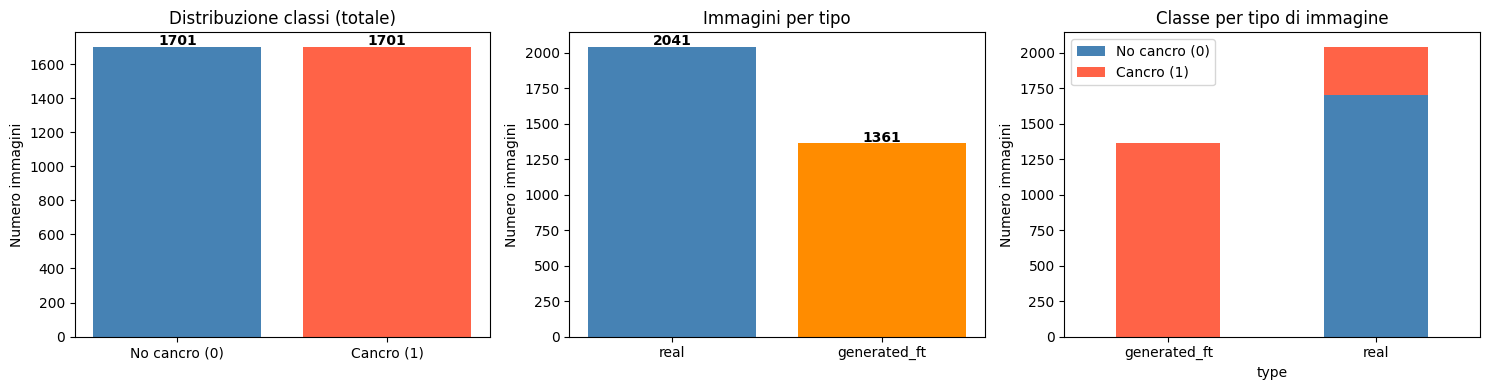

In [6]:
df = df_train_combined

# --- Info base ---
print(f"Shape: {df.shape}")
print(f"\nDistribuzione classi:")
print(df['cancer'].value_counts().rename({0: 'No cancro (0)', 1: 'Cancro (1)'}))
print(f"\nDistribuzione per tipo:")
print(df['type'].value_counts())
print(f"\nCrosstab tipo x classe:")
print(pd.crosstab(df['type'], df['cancer'], colnames=['cancer'], margins=True))

# --- Grafici ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribuzione classi globale
counts = df['cancer'].value_counts().sort_index()
axes[0].bar(['No cancro (0)', 'Cancro (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribuzione classi (totale)')
axes[0].set_ylabel('Numero immagini')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 2. Distribuzione per tipo
type_counts = df['type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color=['steelblue', 'darkorange'])
axes[1].set_title('Immagini per tipo')
axes[1].set_ylabel('Numero immagini')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 3. Stacked bar tipo x classe
ct = pd.crosstab(df['type'], df['cancer'])
ct.plot(kind='bar', stacked=True, ax=axes[2], color=['steelblue', 'tomato'], rot=0)
axes[2].set_title('Classe per tipo di immagine')
axes[2].set_ylabel('Numero immagini')
axes[2].legend(['No cancro (0)', 'Cancro (1)'])

plt.tight_layout()
plt.show()

#### Configurazione

In [8]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 8
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Cartella per salvare i modelli
OUTPUT_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260611_real_synth_efficientnetb3_fine_tuned_0')
os.makedirs(OUTPUT_EXP_DIR, exist_ok=True)

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)
print(OUTPUT_EXP_DIR)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv
../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0


#### Salvataggio configurazione utilizzata per esperimento corrente

In [9]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_EXP_DIR),
    "date": "2026-06-11",
    "backbone": {
        "name": "EfficientNetB3",
        "weights": "imagenet",
        "input_shape": list(IMG_SIZE) + [3],
        "include_top": False,
    },
    "head": {
        "pooling": "GlobalAveragePooling2D",
        "dense_units": 256,
        "l2_regularization": 1e-4,
        "activation": "LeakyReLU(negative_slope=0.1)",
        "dropout": 0.5,
        "output": "Dense(1, sigmoid)",
    },
    "preprocessing": {
        "img_size": list(IMG_SIZE),
        "normalization": "ImageNet mean/std",
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "train_csv": TRAIN_CSV_PATH,
        "val_csv": VAL_CSV_PATH,
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "class_weight": "balanced",
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "focal_loss",
        "focal_loss_gamma": 2.0,
        "focal_loss_alpha": 0.75,
        "max_epochs": 30,
        "fine_tune_from_layer": "block6a_expand_conv",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
        "class_weight": "none",
    },
}

config_path = os.path.join(OUTPUT_EXP_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")


Configurazione esperimento salvata in: ../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0/experiment_config.json


#### Preparazione Dati e Pipeline

In [10]:
# 1. Carica e filtra il CSV
df_train = pd.read_csv(OUTPUT_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

# 2. Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    #img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return img, label
# Niente rotazioni forti, nemmeno zoom

def make_dataset(df, shuffle=False, augment_data=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True, augment_data=False) # Da mettere a True se vuoi data augmentation
val_ds = make_dataset(df_val, shuffle=False, augment_data=False) 

Class Weights: {0: 1.0, 1: 1.0}


#### Costruzione dell'Architettura EfficientNetB3

Creiamo la funzione che istanzia il modello. Inizialmente, congeliamo tutto il backbone (EfficientNetB3) per addestrare solo la nostra testina di classificazione (custom head).

In [11]:
def build_base_model():
    # Carica il backbone EfficientNetB3 pre-addestrato
    base_model = keras.applications.EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )
    
    # Congela il backbone per la Fase 1
    base_model.trainable = False
    
    # Costruisci l'architettura completa
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    
    x = base_model(inputs, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    
    # Output binario (1 neurone con sigmoid)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_base_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,288 (42.64 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

#### Fase 1: Addestramento Custom Head

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'real_synth_efficientnetb3_fase1_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase1
)

Epoch 1/25


I0000 00:00:1781209892.120700    5018 service.cc:153] XLA service 0x76667c09eb50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781209892.120746    5018 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781209894.038471    5018 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781209899.233725    5018 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781209900.823099    5018 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26607__.413
E0000 00:00:1781209905.217305    5018 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781209910.760255    5018 cuda_timer.cc:87] Delay kernel time

424/426 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6500 - auc: 0.6983 - loss: 0.7663 - precision: 0.6409 - recall: 0.6441

I0000 00:00:1781209968.887888    5015 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26607__.413
E0000 00:00:1781209974.304664    5015 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781209975.080625    5015 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781209979.526503    5015 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781209981.051130    5015 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6502 - auc: 0.6985 - loss: 0.7659 - precision: 0.6411 - recall: 0.6442

...

426/426 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7646 - auc: 0.8407 - loss: 0.5463 - precision: 0.7660 - recall: 0.7619 - val_accuracy: 0.5995 - val_auc: 0.5785 - val_loss: 0.7375 - val_precision: 0.1928 - val_recall: 0.4384
Epoch 5/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.7693 - auc: 0.8439 - loss: 0.5429 - precision: 0.7685 - recall: 0.7707 - val_accuracy: 0.6407 - val_auc: 0.5996 - val_loss: 0.6826 - val_precision: 0.2083 - val_recall: 0.4110
Epoch 6/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.7795 - auc: 0.8502 - loss: 0.5318 - precision: 0.7802 - recall: 0.7784 - val_accuracy: 0.7757 - val_auc: 0.6082 - val_loss: 0.5514 - val_precision: 0.2549 - val_recall: 0.1781
Epoch 7/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7925 - auc: 0.8578 - loss: 0.5254 - precision: 0.8050 - recall: 0.7719 - val_accuracy: 0.7185 - val_auc: 0.6194 - val_loss: 0.5877 - val_precision: 0.2222 - val_recall: 0.2740
Epoch 8/25
  5/426 ━━━━━━━━━━━━━━━━

W0000 00:00:1781210167.310338    5439 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777536 bytes after encountering the first element of size 16777536 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


426/426 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.7790 - auc: 0.8585 - loss: 0.5229 - precision: 0.7806 - recall: 0.7760 - val_accuracy: 0.7689 - val_auc: 0.6174 - val_loss: 0.5666 - val_precision: 0.2941 - val_recall: 0.2740
Epoch 9/25
426/426 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7781 - auc: 0.8485 - loss: 0.5362 - precision: 0.7881 - recall: 0.7607 - val_accuracy: 0.6979 - val_auc: 0.6048 - val_loss: 0.6415 - val_precision: 0.2342 - val_recall: 0.3562
Epoch 10/25
  2/426 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9062 - auc: 0.9909 - loss: 0.2940 - precision: 0.8125 - recall: 1.0000  

W0000 00:00:1781210202.198406    5439 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777536 bytes after encountering the first element of size 16777536 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


426/426 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.7895 - auc: 0.8613 - loss: 0.5187 - precision: 0.7944 - recall: 0.7813 - val_accuracy: 0.8124 - val_auc: 0.5839 - val_loss: 0.5475 - val_precision: 0.3714 - val_recall: 0.1781


#### Fase 2: Fine Tuning

In [14]:
base_model.trainable = True
set_trainable = False

for layer in base_model.layers:
    if layer.name == 'block6a_expand_conv': # sblocca ultimi blocchi MBConv (6 e 7) di EfficientNetB3
        set_trainable = True
    layer.trainable = set_trainable

print(f"Totale layer nel base_model: {len(base_model.layers)}")
print(f"Layer addestrabili: {len(model.trainable_variables)}")

def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        # alpha_t: alpha per positivi, (1-alpha) per negativi
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal_weight = alpha_t * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss_fn

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'baseline_efficientnetb3_final_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        mode='max',
        min_lr=1e-7
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    #class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {os.path.join(OUTPUT_EXP_DIR, 'baseline_final_best.keras')}")


Totale layer nel base_model: 385
Layer addestrabili: 113
Epoch 1/30


I0000 00:00:1781210340.535639    5014 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137604__.512
E0000 00:00:1781210349.538805    5014 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781210351.660931    5014 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


425/426 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6533 - auc: 0.6874 - loss: 0.2448 - precision: 0.6558 - recall: 0.6788

I0000 00:00:1781210428.869003    5014 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137604__.512
E0000 00:00:1781210435.993931    5014 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


426/426 ━━━━━━━━━━━━━━━━━━━━ 212s 254ms/step - accuracy: 0.6717 - auc: 0.7244 - loss: 0.2053 - precision: 0.6580 - recall: 0.7149 - val_accuracy: 0.5858 - val_auc: 0.5514 - val_loss: 0.1967 - val_precision: 0.1897 - val_recall: 0.4521 - learning_rate: 1.0000e-05
Epoch 2/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.7119 - auc: 0.7828 - loss: 0.1515 - precision: 0.6873 - recall: 0.7778 - val_accuracy: 0.5858 - val_auc: 0.5700 - val_loss: 0.1717 - val_precision: 0.2065 - val_recall: 0.5205 - learning_rate: 1.0000e-05
Epoch 3/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.7131 - auc: 0.7918 - loss: 0.1384 - precision: 0.6834 - recall: 0.7942 - val_accuracy: 0.6476 - val_auc: 0.5930 - val_loss: 0.1475 - val_precision: 0.2207 - val_recall: 0.4384 - learning_rate: 1.0000e-05
Epoch 4/30
426/426 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.7213 - auc: 0.8071 - loss: 0.1277 - precision: 0.6813 - recall: 0.8319 - val_accuracy: 0.6568 - val_auc: 0.6077 - val_loss: 0

#### Visualizzazione Curve di Training

Analisi Overfitting - Fase 1 (Feature Extraction):
Grafico salvato in: ../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0/figures/training_history_fase1.png


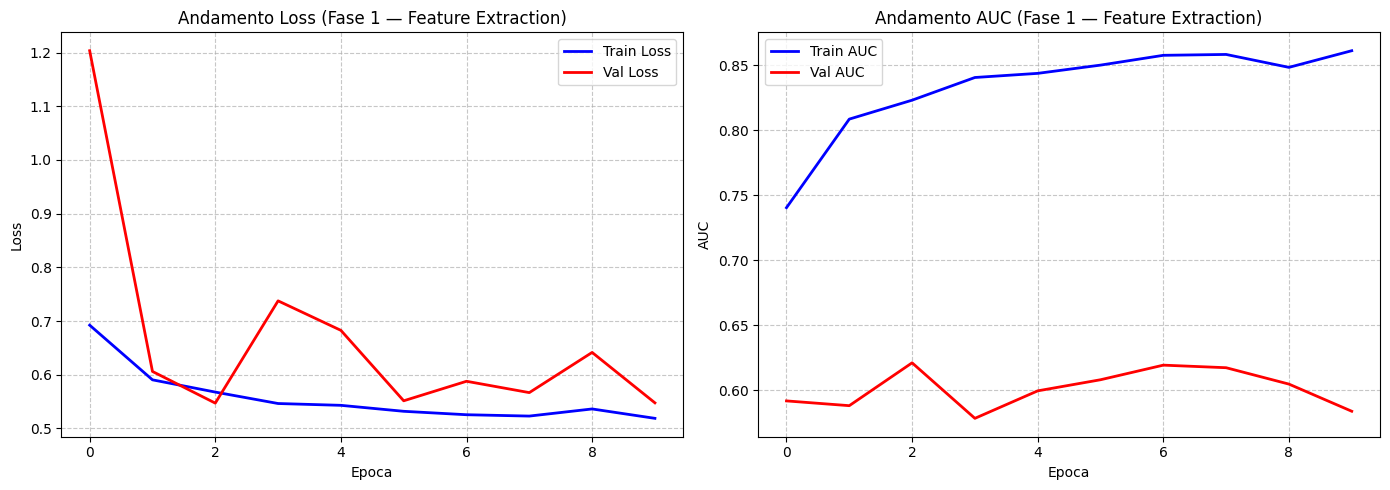

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0/figures/training_history_fase2.png


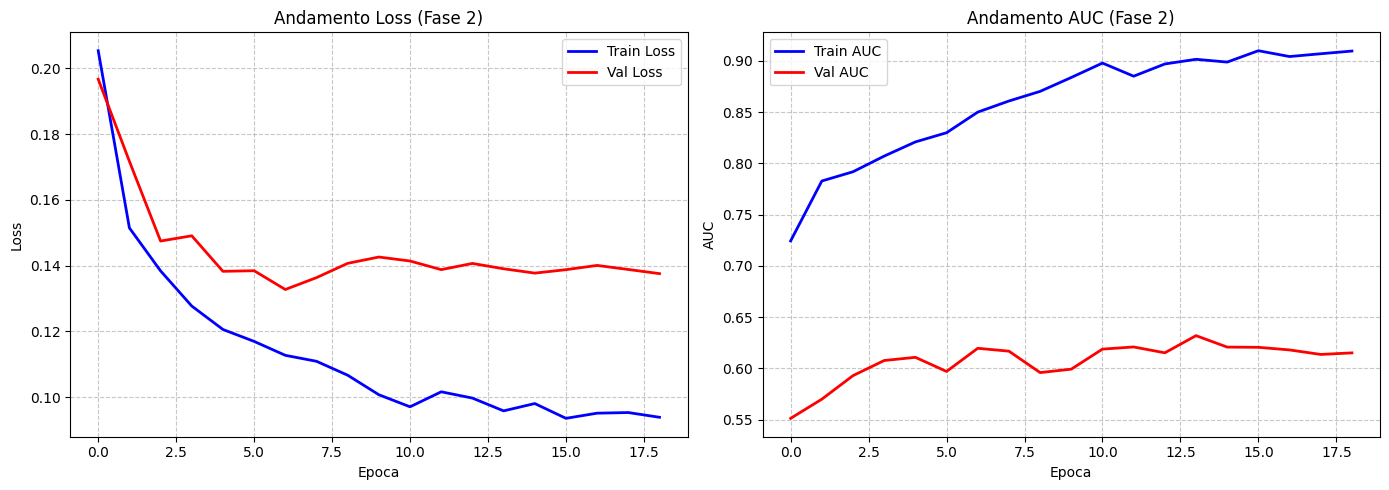

In [15]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Feature Extraction):")
plot_training_history(
    history_phase1, "(Fase 1 — Feature Extraction)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione su Validation Set

AUC: 0.6322
Soglia ottimale: 0.436
              precision    recall  f1-score   support

   No cancro       0.88      0.72      0.79       364
      Cancro       0.27      0.52      0.36        73

    accuracy                           0.69       437
   macro avg       0.58      0.62      0.58       437
weighted avg       0.78      0.69      0.72       437

Metriche salvate in: ../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0/val_metrics.json


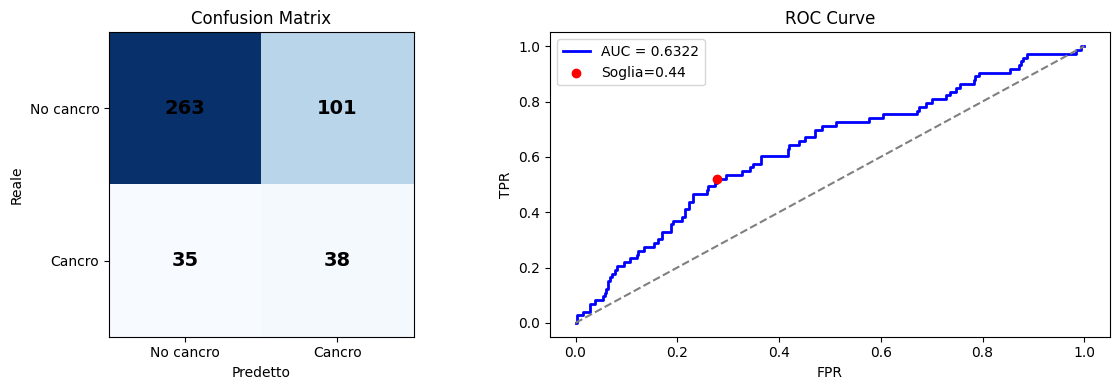

Figura salvata in: ../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0/figures/val_confusion_roc.png


In [16]:
from sklearn.metrics import (confusion_matrix, roc_curve,
                             classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Carica il miglior modello salvato
best_model = keras.models.load_model(
    os.path.join(OUTPUT_EXP_DIR, 'baseline_efficientnetb3_final_best.keras'),
    custom_objects={'loss_fn': focal_loss(gamma=2.0, alpha=0.75)}
)

# Predizioni sul validation set
y_true, y_pred_prob = [], []
for imgs, labels in val_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Soglia ottimale (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_pred_prob >= best_threshold).astype(int)

val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

# Salva metriche in JSON
FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    'split': 'validation',
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_EXP_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

# Figura: Confusion Matrix + ROC curve
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5, label=f'Soglia={best_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")

#### Grad-CAM

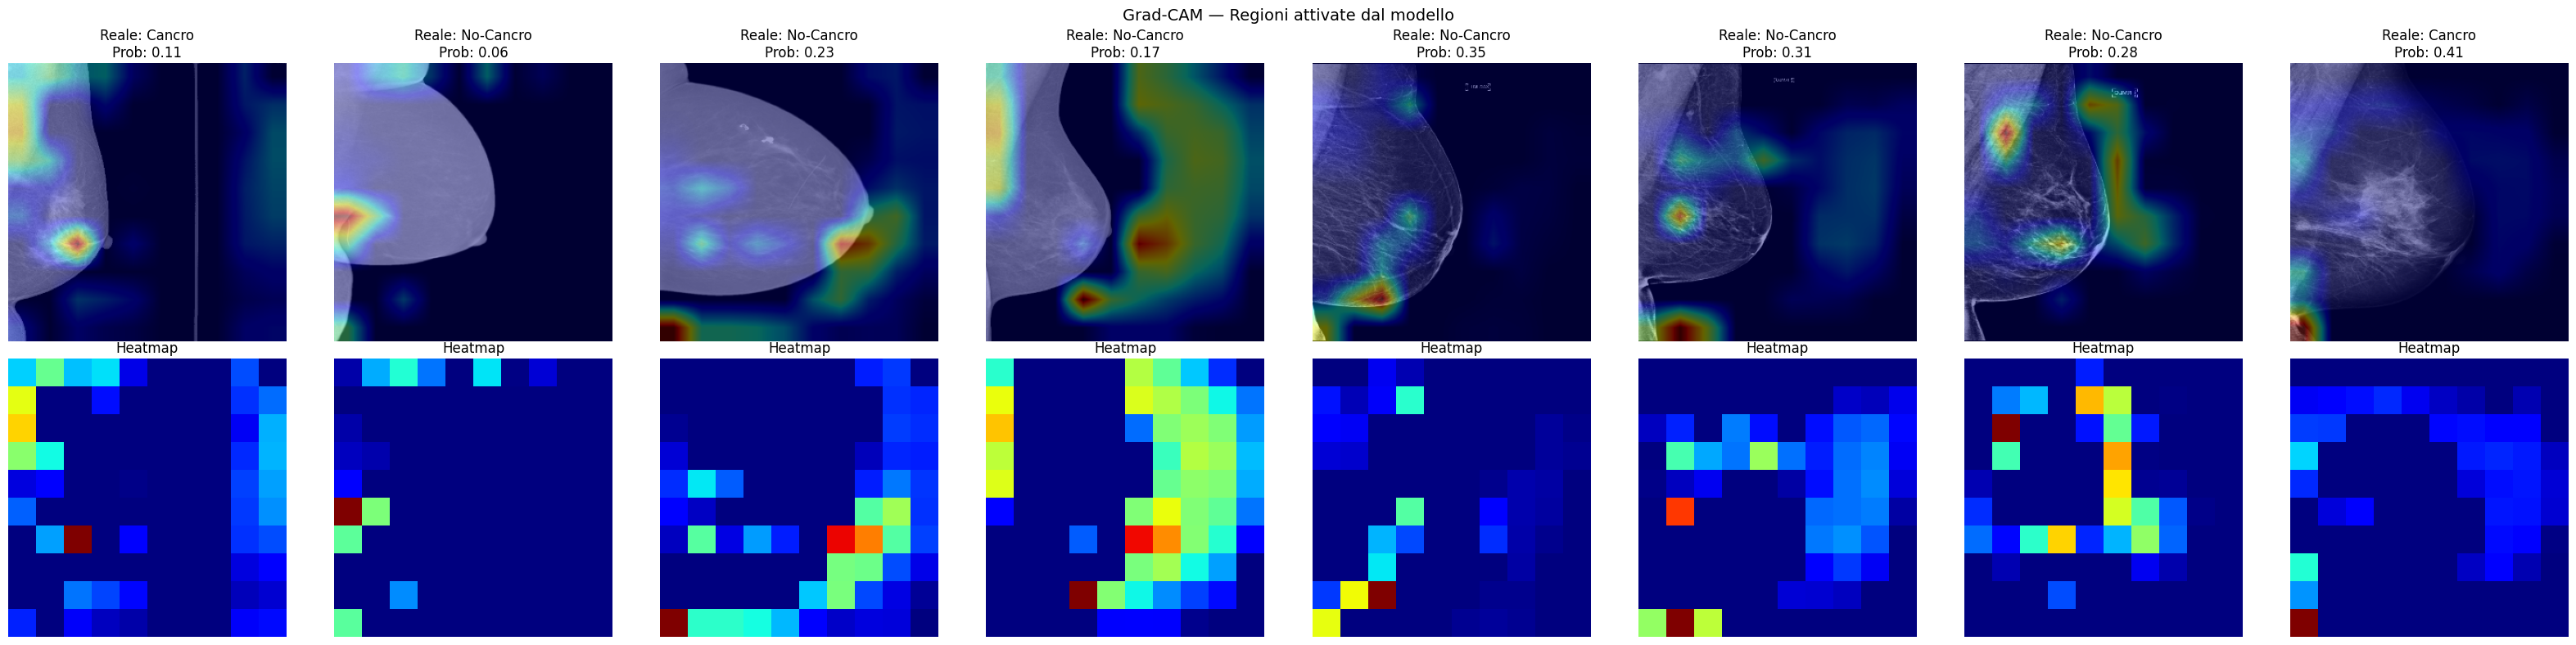

Grad-CAM salvato in: ../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0/figures/gradcam_examples.png


In [19]:
def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('efficientnetb3')
    # Layer dopo il backbone nell'outer model: GAP → Dense → BN → LeakyReLU → Dropout → Dense
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]

    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)  # (1, H, W, 1536) — ha dimensioni spaziali
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x

    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()



def show_gradcam(img_tensor, heatmap, ax, title=""):
    """Sovrappone la heatmap all'immagine originale de-normalizzata."""
    # De-normalizza per visualizzazione
    img_vis = img_tensor.numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_vis = np.clip(img_vis, 0, 1)
    img_vis_gray = img_vis[:, :, 0]  # canale singolo (mammografia)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis_gray, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title)
    ax.axis('off')


# Raccoglie tutte le immagini dal validation set e campiona 8 casuali
all_imgs, all_labels = [], []
for imgs, labels in val_ds:
    for i in range(len(imgs)):
        all_imgs.append(imgs[i])
        all_labels.append(int(labels[i].numpy()))

indices = np.random.choice(len(all_imgs), size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(32, 8))
for col, idx in enumerate(indices):
    img = tf.expand_dims(all_imgs[idx], 0)
    label = all_labels[idx]
    prob = float(best_model.predict(img, verbose=0)[0][0])
    heatmap = make_gradcam_heatmap(img, best_model)

    show_gradcam(all_imgs[idx], heatmap, axes[0, col],
                 title=f"Reale: {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
    axes[1, col].imshow(heatmap, cmap='jet')
    axes[1, col].set_title("Heatmap")
    axes[1, col].axis('off')

plt.suptitle("Grad-CAM — Regioni attivate dal modello", fontsize=14)
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_examples.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM salvato in: {gradcam_path}")

#### Grad-CAM su immagini sintetiche


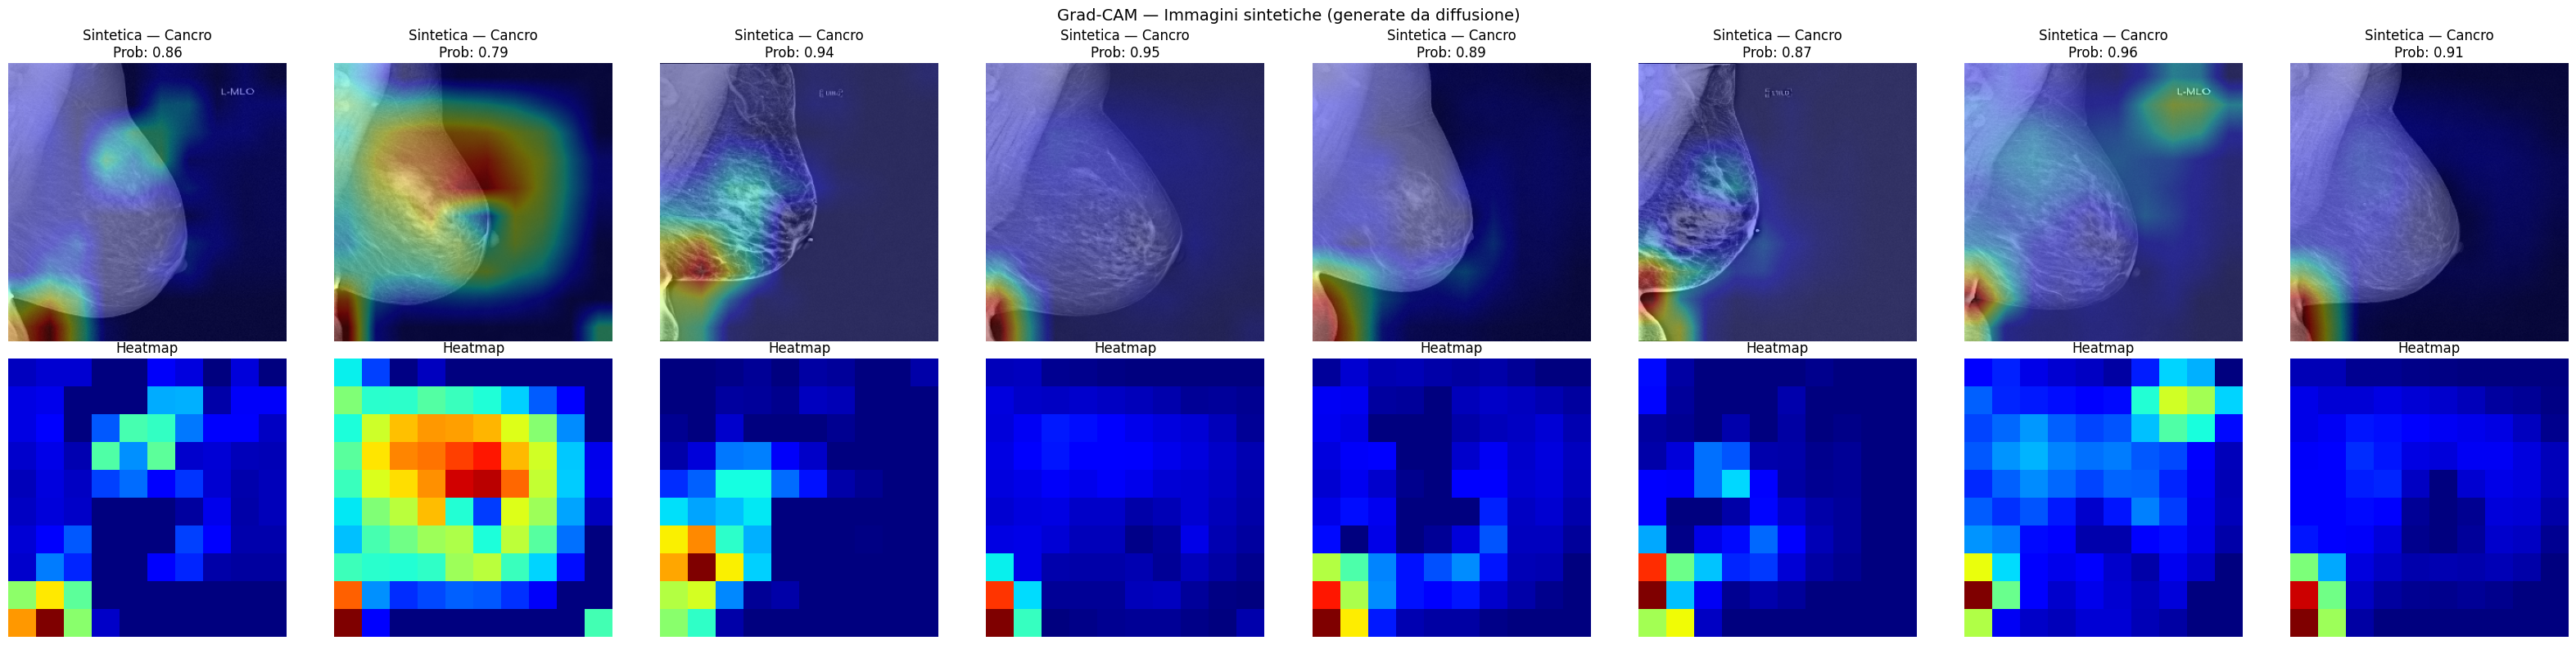

Grad-CAM sintetiche salvato in: ../experiments/exp20260611_real_synth_efficientnetb3_fine_tuned_0/figures/gradcam_synthetic_examples.png


In [22]:
# Dataset con sole immagini sintetiche (tutte cancer=1)
synth_ds = make_dataset(df_synth[['processed_path', 'cancer']], shuffle=False, augment_data=False)

# Raccoglie tutte le immagini sintetiche e campiona 8 casuali
all_synth_imgs, all_synth_labels = [], []
for imgs, labels in synth_ds:
    for i in range(len(imgs)):
        all_synth_imgs.append(imgs[i])
        all_synth_labels.append(int(labels[i].numpy()))

indices_synth = np.random.choice(len(all_synth_imgs), size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(32, 8))
for col, idx in enumerate(indices_synth):
    img = tf.expand_dims(all_synth_imgs[idx], 0)
    label = all_synth_labels[idx]
    prob = float(best_model.predict(img, verbose=0)[0][0])
    heatmap = make_gradcam_heatmap(img, best_model)

    show_gradcam(all_synth_imgs[idx], heatmap, axes[0, col],
                 title=f"Sintetica — {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
    axes[1, col].imshow(heatmap, cmap='jet')
    axes[1, col].set_title("Heatmap")
    axes[1, col].axis('off')

plt.suptitle("Grad-CAM — Immagini sintetiche (generate da diffusione)", fontsize=14)
plt.tight_layout()
gradcam_synth_path = os.path.join(FIGURES_DIR, 'gradcam_synthetic_examples.png')
fig.savefig(gradcam_synth_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM sintetiche salvato in: {gradcam_synth_path}")